#PCA Based Dimensionality Reduction and Chemical Segmentation of Positive-Ion TOF-SIMS Data using Total Ion Count Normalization

Gayathri Emuru

**Index**

* Abstract
* Data Preprocessing
* PCA Implementation
* K-Means Implementation
* Silhouette Score Calculation

## Abstract

Time-of-Flight Secondary Ion Mass Spectrometry ([ToF-SIMS](https://www.sciencedirect.com/topics/chemistry/time-of-flight-secondary-ion-mass-spectrometry)) is a surface analysis technique that uses a pulsed primary-ion beam (e.g., Bi⁺, Au₃⁺) to sputter secondary ions from a sample—in this case, a salad lid container provided by the 3M team. These ions are then accelerated and travel through a controlled path, where their arrival times are measured to generate a mass spectrum.

Each imaging pixel at spatial coordinates
(x pixel,y pixel) yields an ion-intensity vector over m/z channels(1-2054), where channel intensities correspond to counts of secondary ions of that mass-to-charge ratio.

**Preprocessing Steps**



**TIC(Total Ion Count) Calculation:** Summing intensities across all mass channels for each pixel, then stores the result as a new TIC column. TIC is used as a normalization factor to correct for overall signal intensity differences across pixels.

**TIC(Total Ion Count) Normalization:** Divides each pixel's mass channel intensities by the pixel's TIC (using a safe replacement for zeros). Normalizing by TIC compensates for variability in total signal, ensuring that further statistical analysis (like PCA) focuses on relative differences in spectral shape rather than absolute intensity.

**Poisson Scaling and Mean-Centering:** Applies a square-root transformation (Poisson scaling) to stabilize variance, then centers the data by subtracting the mean of each mass channel. These transformations reduce heteroscedasticity (variance differences) and help meet the assumptions necessary for effective PCA/MCR analysis.

Referenced papers: [paper 1](https://pubs.aip.org/avs/jva/article/42/2/023204/3261927/Novel-principal-component-analysis-tool-based-on)


Principal Component Analysis ([PCA](https://en.wikipedia.org/wiki/Principal_component_analysis)) is a dimensionality reduction technique that identifies orthogonal directions capturing maximal variance in high-dimensional data. By normalizing the data and computing principal components, PCA transforms the dataset into a lower-dimensional space while retaining essential features. A scree plot is used to determine the number of components that explain a predefined variance threshold (e.g., 90%). PCA can reduce data to two dimensions by selecting the top two components and projecting the dataset onto them, enabling easier visualization and analysis.

Following PCA, K-Means clustering is applied to categorize the data. An elbow plot of the within-cluster sum of squares (WCSS) helps determine the optimal number of clusters by identifying the point where adding more clusters no longer significantly reduces WCSS. Using this criterion, K-Means partitions the PCA-transformed data into chemically distinct groups, facilitating structured analysis.

By integrating PCA and K-Means, high-dimensional data becomes more interpretable, helping to uncover meaningful patterns and improve data-driven insights.

**Installing packages**

In [ ]:
!pip install umap-learn

**Importing the Necessary Modules**

In [ ]:
# Importing the Necessary Modules

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize, ListedColormap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap
from sklearn.cluster import KMeans
import math

##PreProcessing the Positive Ion Data Set



In [ ]:
# Load the data
binned_positive_df_file_path = "/content/drive/Shareddrives/3M Hackathon Team/Data/BINNED_1AMU_SPECTRA_lids_07_Pos_salad lid_XYMassShiftCorrected_ZMassShiftCorrected.csv"
binned_positive_df = pd.read_csv(binned_positive_df_file_path)

# Print the shape of binned_positive_df
print(f"Data shape (pixels x columns): {binned_positive_df.shape}")

# Display the list of column names binned_positive_df
print("Positive Ion Data (first 5 rows):", binned_positive_df.head())

# Replace missing values (NaN) with 0
binned_positive_df.fillna(0, inplace=True)

# check for duplicates
duplicates = binned_positive_df.duplicated()
print(f"Number of duplicate rows: {duplicates.sum()}")

Data shape (pixels x columns): (65536, 2047)
Positive Ion Data (first 5 rows):    x  y   1   2   3   4   5   6   7   8  ...  2036  2037  2038  2039  2040  \
0  0  0 NaN NaN NaN NaN NaN NaN NaN NaN  ...   NaN   NaN   NaN   NaN   NaN   
1  0  1 NaN NaN NaN NaN NaN NaN NaN NaN  ...   NaN   NaN   NaN   NaN   NaN   
2  0  2 NaN NaN NaN NaN NaN NaN NaN NaN  ...   NaN   NaN   NaN   NaN   NaN   
3  0  3 NaN NaN NaN NaN NaN NaN NaN NaN  ...   NaN   NaN   NaN   NaN   NaN   
4  0  4 NaN NaN NaN NaN NaN NaN NaN NaN  ...   NaN   NaN   NaN   NaN   NaN   

   2041  2042  2043  2044  2045  
0   NaN   NaN   NaN   NaN   NaN  
1   NaN   NaN   NaN   NaN   NaN  
2   NaN   NaN   NaN   NaN   NaN  
3   NaN   NaN   NaN   NaN   NaN  
4   NaN   NaN   NaN   NaN   NaN  

[5 rows x 2047 columns]
Number of duplicate rows: 0


In [ ]:
# Create list of mass channel names from 1 to 2045
mz_columns = [str(m) for m in range(1, 2046)]

# Compute Total Ion Count (TIC) for each pixel by summing intensities over all mass channels
tic_values = binned_positive_df.loc[:, mz_columns].sum(axis=1)
binned_positive_df['TIC'] = tic_values

print("First 5 TIC values:", binned_positive_df['TIC'].head().tolist())


First 5 TIC values: [78.0, 91.0, 61.0, 101.0, 64.0]


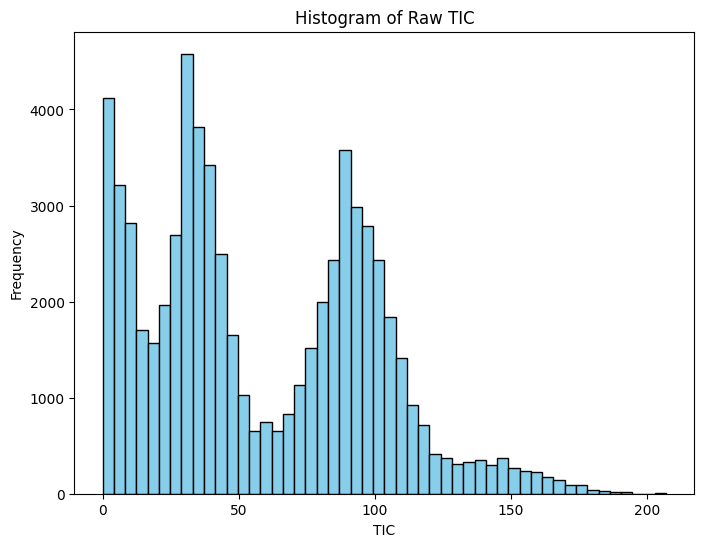

In [ ]:
# Plot a histogram of the Total Ion Count (TIC)
plt.figure(figsize=(8,6))
plt.hist(binned_positive_df['TIC'], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of Raw TIC")
plt.xlabel("TIC")
plt.ylabel("Frequency")
plt.show()

The raw TIC histogram shows a wide, uneven distribution, indicating that some spectra have very high or very low signals, which may include noise. After preprocessing (normalizing, square-root transforming, and mean-centering), the histogram (or a representative channel's histogram) becomes more compact and centered.This change confirms that our data are now on a common, stable scale—making the subsequent analyses (like PCA) more reliable and focused on true chemical differences rather than instrument noise. So proceeding with the TIC normalization and further preprocessing.

In [ ]:
# Normalize spectral intensities by dividing each intensity by the pixel's TIC (avoid division by zero)
tic = binned_positive_df['TIC'].replace(0, 1)  # Replace zeros in TIC with 1 to prevent division errors
binned_positive_df[mz_columns] = binned_positive_df[mz_columns].div(tic, axis=0)  # Normalize each mass channel by TIC
binned_positive_df['Normalized_TIC'] = binned_positive_df[mz_columns].sum(axis=1)

<ipython-input-6-ac4cba36c5f7>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  binned_positive_df['Normalized_TIC'] = binned_positive_df[mz_columns].sum(axis=1)


In [ ]:
# Apply Poisson scaling using square-root transform and mean-center the data for variance stabilization
binned_positive_df[mz_columns] = np.sqrt(binned_positive_df[mz_columns])  # Poisson scaling (sqrt transform)
means = binned_positive_df[mz_columns].mean(axis=0)  # Compute mean of each mass channel
binned_positive_df[mz_columns] = binned_positive_df[mz_columns] - means  # Mean-center the mass channel intensities

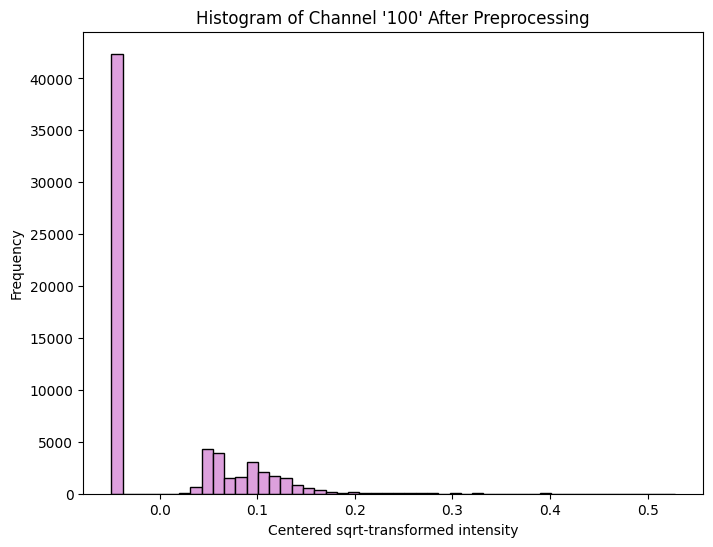

In [ ]:
# Plot a histogram of the Centered sqrt-transformed intensity
plt.figure(figsize=(8,6))
plt.hist(binned_positive_df["100"], bins=50, color='plum', edgecolor='black')
plt.title("Histogram of Channel '100' After Preprocessing")
plt.xlabel("Centered sqrt-transformed intensity")
plt.ylabel("Frequency")
plt.show()

After scaling and mean centering, the histogram for a 100 mass channel shows that most transformed intensity values cluster around zero with fewer extreme values. This compact, centered distribution indicates that the data's overall bias and variability have been minimized. Consequently, the dataset is now better aligned and more uniform, which is crucial before running dimensionality reduction techniques such as PCA. This preprocessing ensures that downstream analyses will focus on genuine chemical differences rather than artifacts from signal intensity disparities.

## Analysing the Positive Ion Data Set

In [ ]:
# Print the full list of column names to review all mass channels
print("Column names:")
print(binned_positive_df.columns.tolist())

# Show DataFrame info—includes non-null counts and dtypes—for a complete structural overview
print("DataFrame info:")
binned_positive_df.info()

Column names:
['x', 'y', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155'

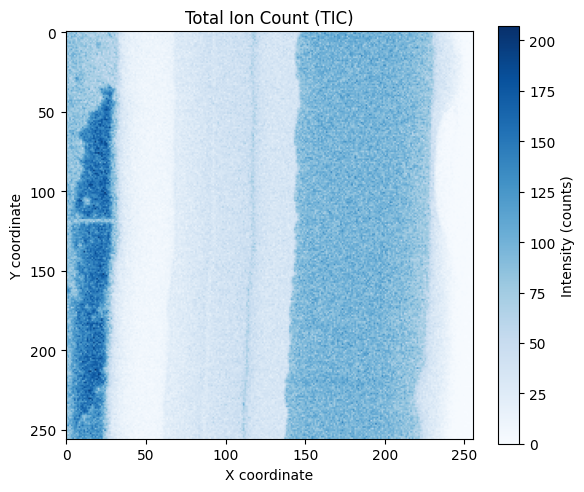

In [ ]:
# image dimensions from x and y ranges
max_x = binned_positive_df['x'].max()
max_y = binned_positive_df['y'].max()
width = max_x + 1
height = max_y + 1

# Create a 2D array for TIC values
tic_image = np.zeros((height, width))
x_coords = binned_positive_df['x'].astype(int).to_numpy()
y_coords = binned_positive_df['y'].astype(int).to_numpy()
tic_array = binned_positive_df['TIC'].to_numpy()
tic_image[y_coords, x_coords] = tic_array

# Visualize TIC image
fig = plt.figure(figsize=(6, 5))
plt.imshow(tic_image, cmap='Blues')
plt.title("Total Ion Count (TIC)")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.colorbar(label="Intensity (counts)")
plt.tight_layout()
plt.show()

# Save the figure using pickle
with open("tic_figure.pkl", "wb") as f:
    pickle.dump(fig, f)

The heatmap shows the spatial distribution of TIC values across the x-y grid. Areas with higher TIC values are represented by warmer colors (red/yellow), while regions with lower TIC values are cooler (blue).
The heatmap reveals spatial variations in Total Ion Count (TIC), with higher ion abundance concentrated in specific regions and lower intensity in others.

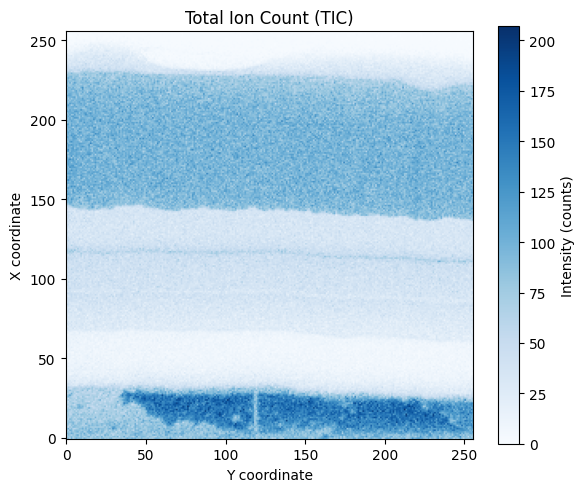

In [ ]:
# Rotate the TIC image by swapping X and Y axes
fig = plt.figure(figsize=(6, 5))
plt.imshow(tic_image.T, cmap='Blues', origin='lower')  # Transpose the array to swap axes
plt.title("Total Ion Count (TIC)")
plt.xlabel("Y coordinate")  # X becomes Y
plt.ylabel("X coordinate")  # Y becomes X
plt.colorbar(label="Intensity (counts)")
plt.tight_layout()
plt.show()

# Save the figure using pickle
with open("rotate_tic_figure.pkl", "wb") as f:
    pickle.dump(fig, f)

In [ ]:
# Duplicate the original DataFrame to preserve full data
df_full = binned_positive_df.copy()

# Drop columns from the original DataFrame for PCA
columns_to_drop = ['TIC', 'Normalized_TIC']
binned_positive_df = binned_positive_df.drop(columns=[col for col in columns_to_drop
                                                       if col in binned_positive_df.columns])
print("Columns after dropping extra columns for PCA:")
print(binned_positive_df.columns.tolist())


Columns after dropping extra columns for PCA:
['x', 'y', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '

## PCA Implementation

**Plot the scree plot**

Standard PCA:


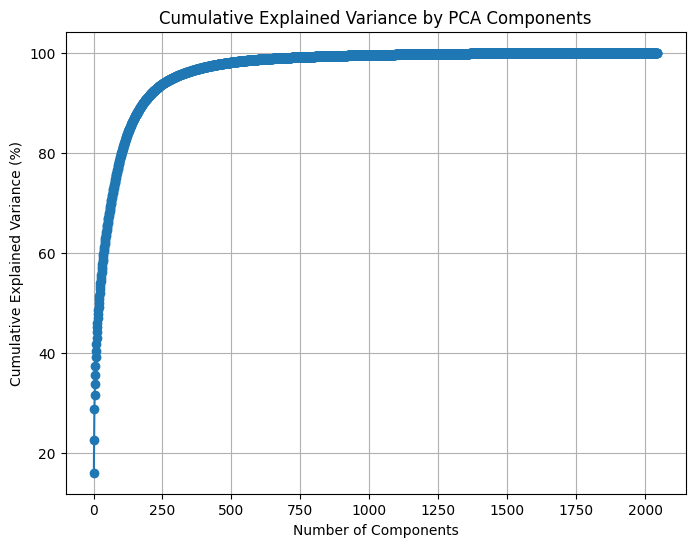

In [ ]:
# Convert processed m/z feature data to numpy array
X = binned_positive_df[mz_columns].to_numpy()
X = np.nan_to_num(X, nan=0.0)

# Perform PCA and plot explained variance for all components
def plot_pca_variance(data, max_components=None):
    pca = PCA()
    scores = pca.fit_transform(data)
    explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_) * 100

    # Plot cumulative explained variance ratio
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o', linestyle='-')
    plt.title("Cumulative Explained Variance by PCA Components")
    plt.xlabel("Number of Components")
    plt.ylabel("Cumulative Explained Variance (%)")
    plt.grid()
    plt.show()

print("Standard PCA:")
plot_pca_variance(X)

PCA is fitted to the data to transform it into principal components. and Calculates the cumulative explained variance ratio, showing how much of the total variance is captured by an increasing number of components.

The curve explains how much variance explained as more components are added.

Around 200 principal compoennts its explaining the cumulative explained variance of 98% and around 250 components around 94%.

### PCA with 500 components

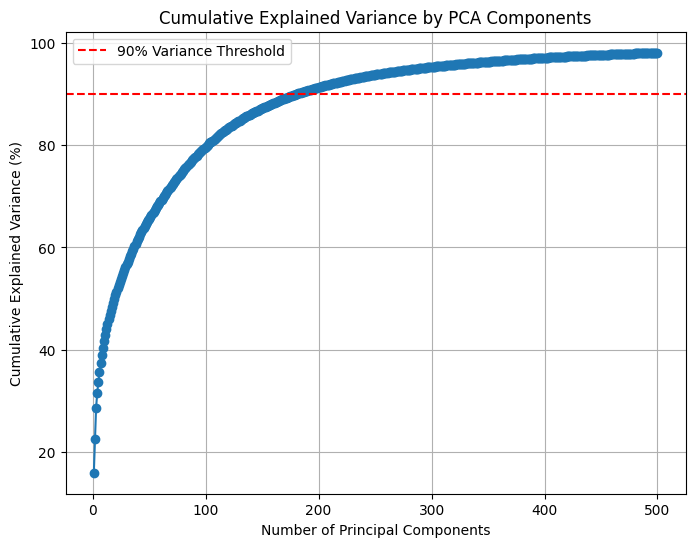

Total explained variance for the first 40 components: 61.66%


In [ ]:
# Perform PCA for 500 components and analyze variance (refer to "PCA and MCR" section in Stuart’s paper)
pca = PCA(n_components=500, random_state=42)
scores = pca.fit_transform(X)  # Transform the data into 40 principal components
explained_var = pca.explained_variance_ratio_  # Get the variance ratio for each component
cumulative_explained_var = np.cumsum(explained_var) * 100  # Compute cumulative explained variance in percent

# Plot cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_explained_var) + 1), cumulative_explained_var, marker='o', linestyle='-')
plt.axhline(y=90, color='r', linestyle='--', label="90% Variance Threshold")
plt.title("Cumulative Explained Variance by PCA Components")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.grid()
plt.legend()
plt.show()

# Calculate and print total explained variance for the first 40 components
total_explained_variance = np.sum(explained_var[:40]) * 100
print(f"Total explained variance for the first 40 components: {total_explained_variance:.2f}%")


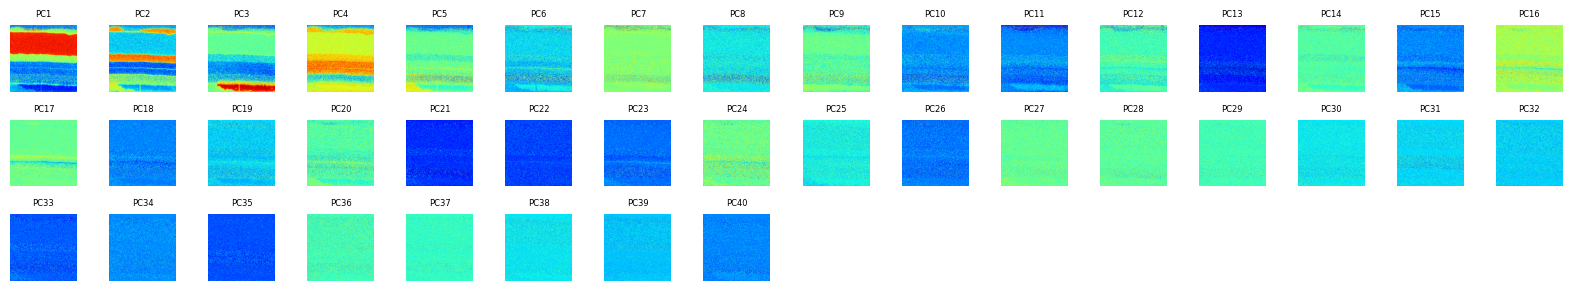

In [ ]:
# Define spatial dimensions
img_height = 256
img_width = 256
n_components = 40

# Set up the grid layout: 16 columns, ceil(40/16)=3 rows
ncols = 16
nrows = math.ceil(n_components / ncols)

# Create a grid of subplots
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 1.0))
axes = axes.flatten()

# Loop over all 40 PCA components
for i in range(n_components):
    comp_image = scores[:, i].reshape(img_height, img_width)
    ax = axes[i]
    ax.imshow(comp_image, cmap='jet', origin='lower')
    ax.set_title(f"PC{i+1}", fontsize=6)
    ax.axis('off')

# Hide any excess axes
for ax in axes[n_components:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

This plot explains how each of the 40 principal components captures distinct spatial patterns of variance across the sample. Components with warm and widespread colors indicate areas contributing significantly to the chemical or physical features extracted by PCA, while cooler regions contribute less. By visualizing all components, we observe that the dominant variance is often localized, suggesting PCA's effectiveness in isolating meaningful spatial domains. This comprehensive mapping underscores how PCA efficiently reduces high-dimensional data, retaining key spatial features while minimizing noise and redundancy.

In [ ]:
# Compute and print the total explained variance for the first 40 components
total_variance_percent = np.sum(explained_var[:40]) * 100
print(f"Total explained variance for the first 40 components: {total_variance_percent:.2f}%")

# Print explained variance for each component
print("Explained variance for each component:")
for comp_idx, ratio in enumerate(explained_var, start=1):
    print(f"Component {comp_idx}: {ratio:.8f} explained variance")

Total explained variance for the first 40 components: 61.66%
Explained variance for each component:
Component 1: 0.15975990 explained variance
Component 2: 0.06634456 explained variance
Component 3: 0.06068325 explained variance
Component 4: 0.02876922 explained variance
Component 5: 0.02180108 explained variance
Component 6: 0.01857065 explained variance
Component 7: 0.01768717 explained variance
Component 8: 0.01678562 explained variance
Component 9: 0.01358269 explained variance
Component 10: 0.01354653 explained variance
Component 11: 0.01199955 explained variance
Component 12: 0.01140694 explained variance
Component 13: 0.00970196 explained variance
Component 14: 0.00952759 explained variance
Component 15: 0.00840412 explained variance
Component 16: 0.00804682 explained variance
Component 17: 0.00790552 explained variance
Component 18: 0.00775361 explained variance
Component 19: 0.00739937 explained variance
Component 20: 0.00711153 explained variance
Component 21: 0.00697706 expl

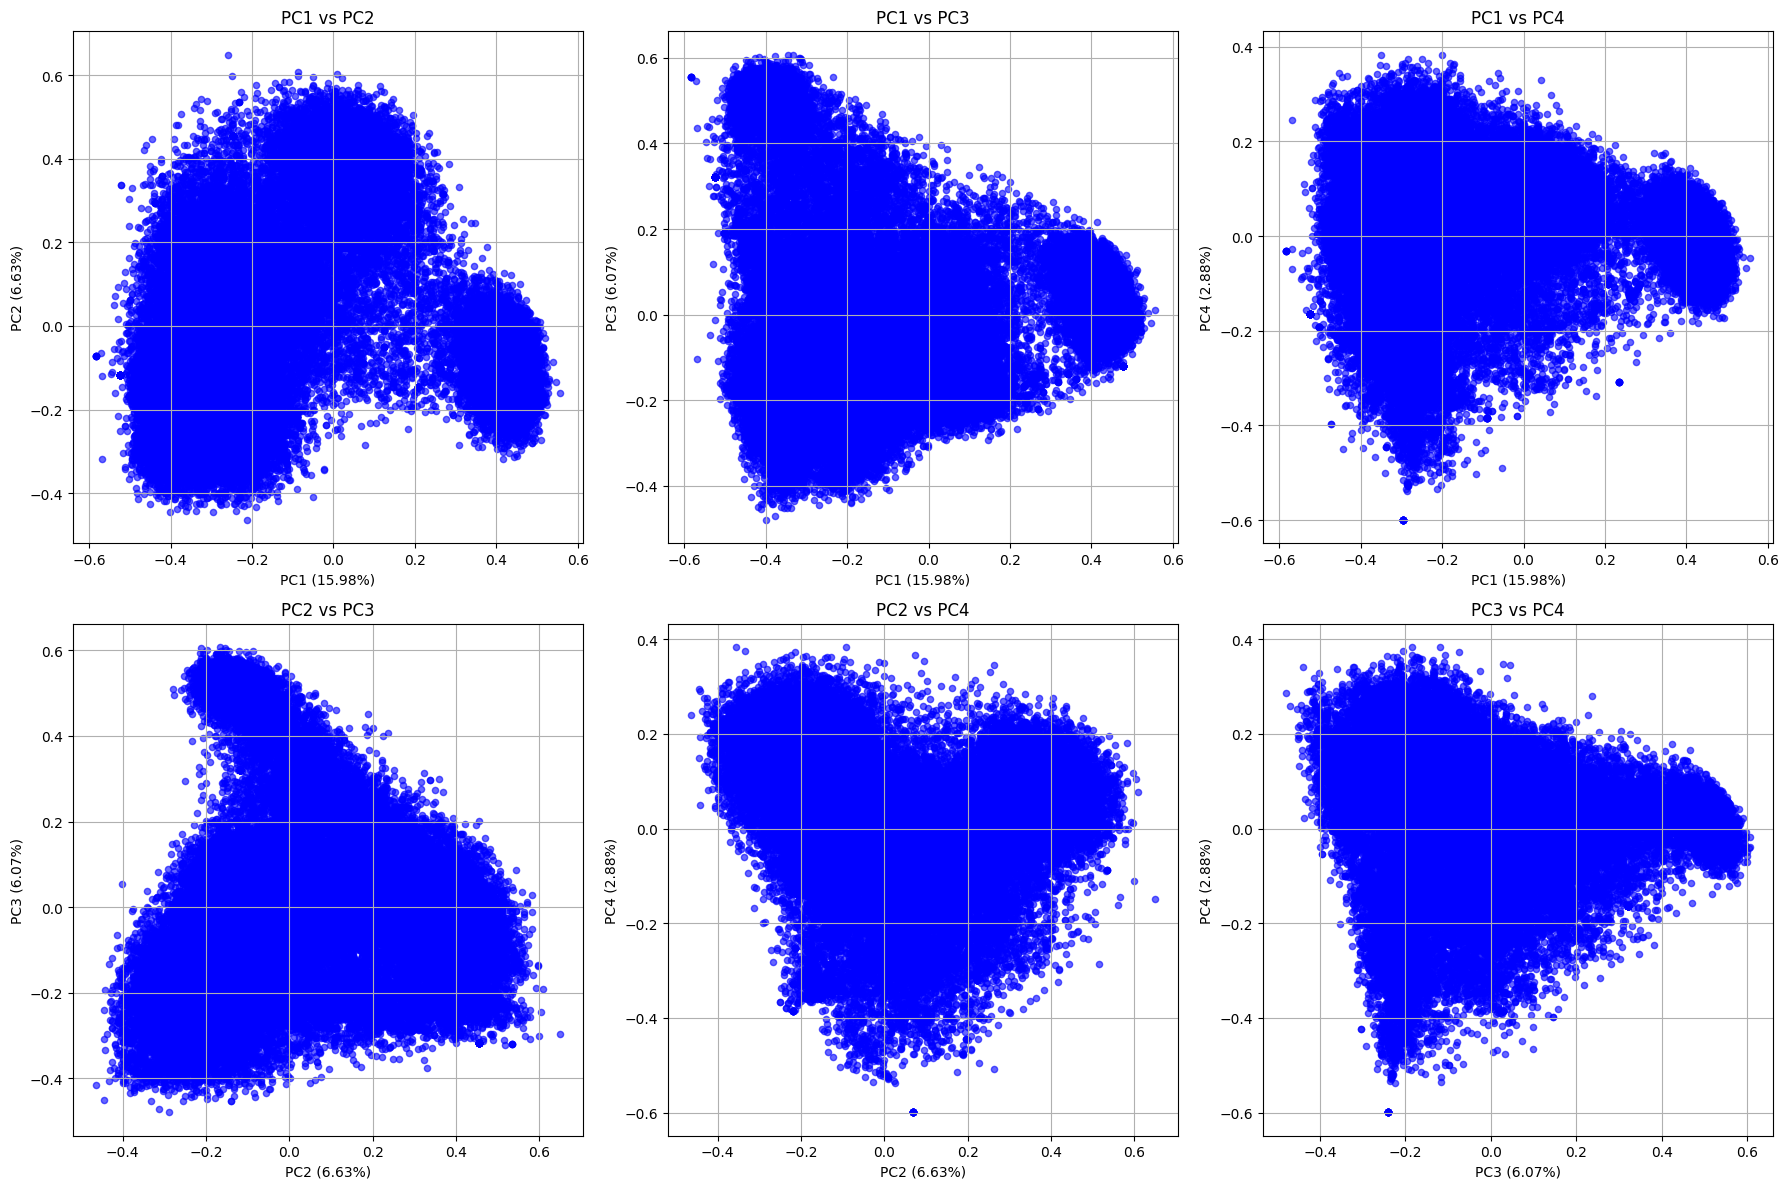

In [ ]:
# Function to create pairwise scatter plots for selected PCA component pairs
def plot_pairwise_pcs(scores, explained_var, pairs, fig_size=(18, 12)):
    n_plots = len(pairs)
    ncols = 3
    nrows = (n_plots + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=fig_size)
    axes = axes.flatten() if n_plots > 1 else [axes]

    for i, (pcx, pcy) in enumerate(pairs):
        ax = axes[i]
        ax.scatter(scores[:, pcx], scores[:, pcy], s=20, alpha=0.6, color='blue')
        ax.set_xlabel(f'PC{pcx+1} ({explained_var[pcx]*100:.2f}%)')
        ax.set_ylabel(f'PC{pcy+1} ({explained_var[pcy]*100:.2f}%)')
        ax.set_title(f'PC{pcx+1} vs PC{pcy+1}')
        ax.grid(True)

    # Hide any unused subplots in the grid layout to avoid empty plots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

# Define pairs of PCA components to visualize: for example, PC1 vs PC2, PC1 vs PC3, etc.
pairs_to_plot = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
plot_pairwise_pcs(scores, explained_var, pairs_to_plot, fig_size=(18, 12))


The pairwise PCA scatter plots shows how much of the data variance is captured by the first few components, ideally revealing clusters that indicate differences in ion features as seen in similar studies. However, since our plots use a uniform blue color without additional color mapping, no distinct clusters are highlighted—suggesting that either the chemical variations are more gradual or that additional clustering techniques may be needed to uncover subtle groupings in the ToF-SIMS spectra.

### K-means spatial distribution

In [ ]:
# Visualize the spatial distribution of the first principal component
plt.figure(figsize=(8, 6))
plt.scatter(binned_positive_df['x'], binned_positive_df['y'], c=scores[:, 0], cmap='tab10', s=5)
plt.colorbar(label='PC1 Score')
plt.title('Spatial Distribution of PC1')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

# Visualize the spatial distribution of the second principal component
plt.figure(figsize=(8, 6))
plt.scatter(binned_positive_df['x'], binned_positive_df['y'], c=scores[:, 1], cmap='tab10', s=5)
plt.colorbar(label='PC2 Score')
plt.title('Spatial Distribution of PC2')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()


The spatial distribution of the PC1 score maps each pixel's value from the first principal component onto its corresponding (x, y) location, revealing how the dominant variance in the data is arranged spatially. In essence, areas with high PC1 scores (shown in warmer colors) indicate regions with strong contributions from the key chemical or physical features, while lower scores (cooler colors) indicate regions with less of those features. This visualization helps identify distinct spatial patterns and heterogeneities within the dataset.

### Pca with 40 components with t_SNE

In [ ]:
# Perform PCA with 40 components on the input data matrix X
pca_40 = PCA(n_components=40, random_state=42)
pca_40_scores = pca_40.fit_transform(X)

/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


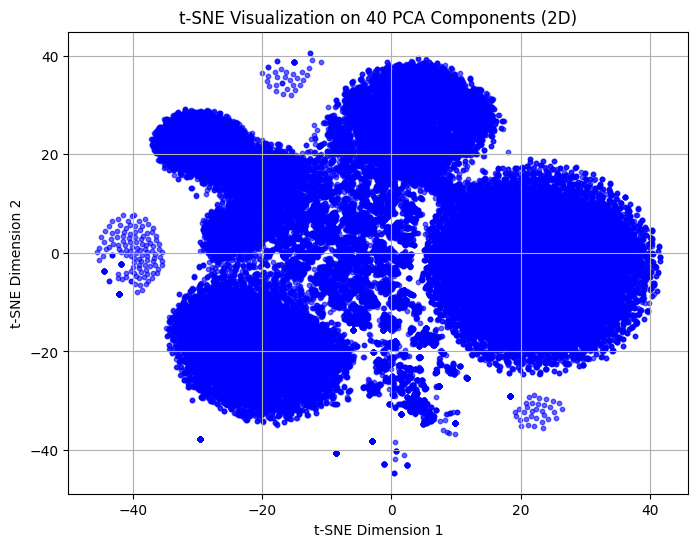

In [ ]:
# Apply t-SNE directly on the 40 PCA components to reduce data to 2 dimensions
tsne = TSNE(n_components=2, random_state=42, perplexity=30, learning_rate=200, n_iter=1000)
tsne_scores = tsne.fit_transform(pca_40_scores)

# Plot the 2D t-SNE scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(tsne_scores[:, 0], tsne_scores[:, 1], s=10, alpha=0.6, color='blue')
plt.title("t-SNE Visualization on 40 PCA Components (2D)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid()
plt.show()

### PCA with 40 components with K-means

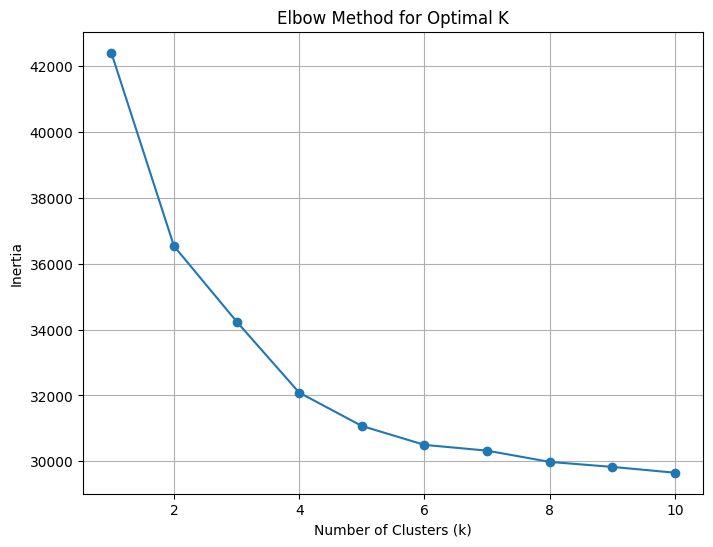

In [ ]:
# Initialize lists and dictionaries to store inertia values and clustering models
cluster_inertias = []
kmeans_models_dict = {}

# Loop through different numbers of clusters (k = 1 to 10) using the Elbow Method
for num_clusters in range(1, 11):
    kmeans_model = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_model.fit(scores)
    cluster_inertias.append(kmeans_model.inertia_)
    kmeans_models_dict[num_clusters] = kmeans_model

# Plot the Elbow Method graph to identify the optimal number of clusters
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), cluster_inertias, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid()
plt.show()

The elbow method plot displays the total within-cluster variance (inertia) as a function of the number of clusters. An elbow at k = 8 indicates that increasing clusters beyond 8 offers little additional improvement, suggesting that 8 clusters effectively capture the key structure of the PCA-transformed positive ion dataset without overcomplicating the model.

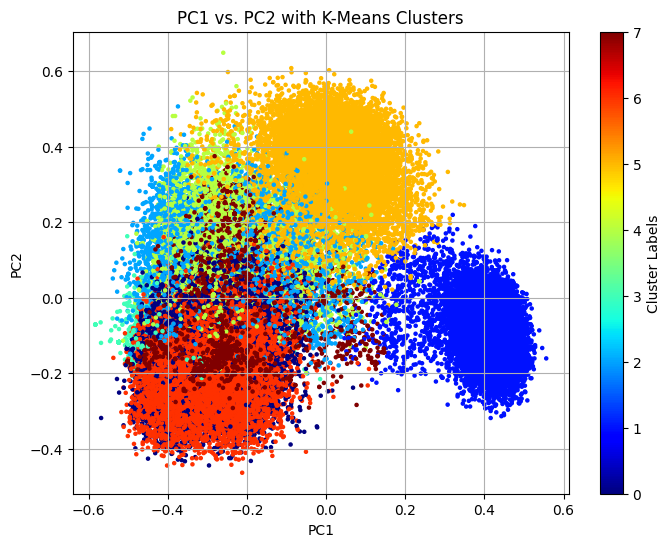

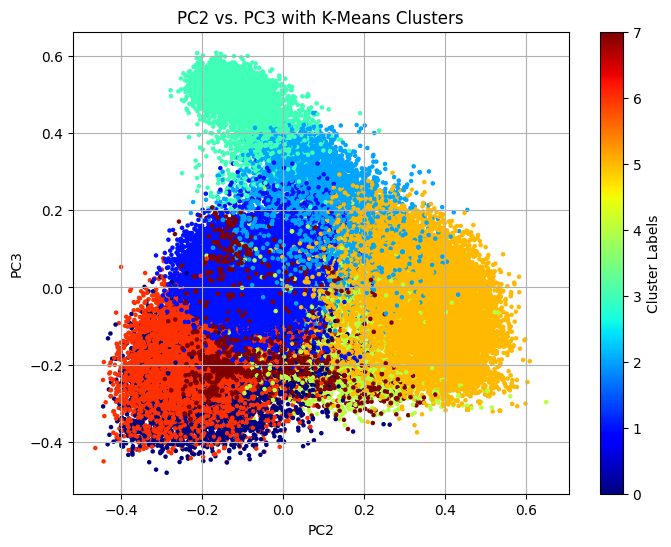

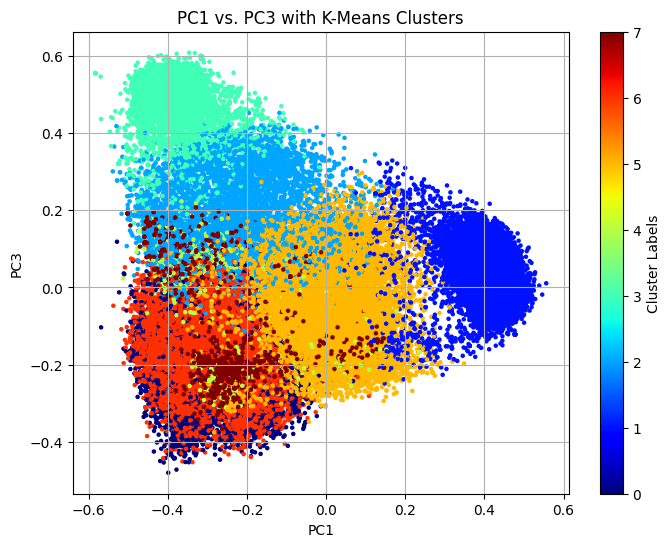

In [ ]:
# Fit the final K-Means clustering model using PCA-transformed data (pca_40_scores)
optimal_clusters = 8
final_kmeans_model = KMeans(n_clusters=optimal_clusters, random_state=42)
final_kmeans_model.fit(pca_40_scores)

# Visualize clustering results in PCA space (PC1 vs. PC2)
plt.figure(figsize=(8, 6))
plt.scatter(pca_40_scores[:, 0], pca_40_scores[:, 1], c=final_kmeans_model.labels_, cmap='jet', s=5)
plt.title("PC1 vs. PC2 with K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Cluster Labels")
plt.grid(True)
plt.show()

# Visualize clustering results in PCA space (PC2 vs. PC3)
plt.figure(figsize=(8, 6))
plt.scatter(pca_40_scores[:, 1], pca_40_scores[:, 2], c=final_kmeans_model.labels_, cmap='jet', s=5)
plt.title("PC2 vs. PC3 with K-Means Clusters")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Labels")
plt.grid(True)
plt.show()

# Visualize clustering results in PCA space (PC1 vs. PC3)
plt.figure(figsize=(8, 6))
plt.scatter(pca_40_scores[:, 0], pca_40_scores[:, 2], c=final_kmeans_model.labels_, cmap='jet', s=5)
plt.title("PC1 vs. PC3 with K-Means Clusters")
plt.xlabel("PC1")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Labels")
plt.grid(True)
plt.show()


We applied K-Means clustering on the PCA-transformed positive ion dataset (pca_40_scores) using eight clusters—this number was selected based on the elbow method that showed diminishing improvements beyond eight clusters. The PCA space (PC1 vs. PC2, PC2 vs. PC3, and PC1 vs. PC3) visualizations reveal how the clusters separate in reduced dimensions, providing insights into underlying chemical and spatial structures. This approach follows best practices from advanced ToF-SIMS data analysis.

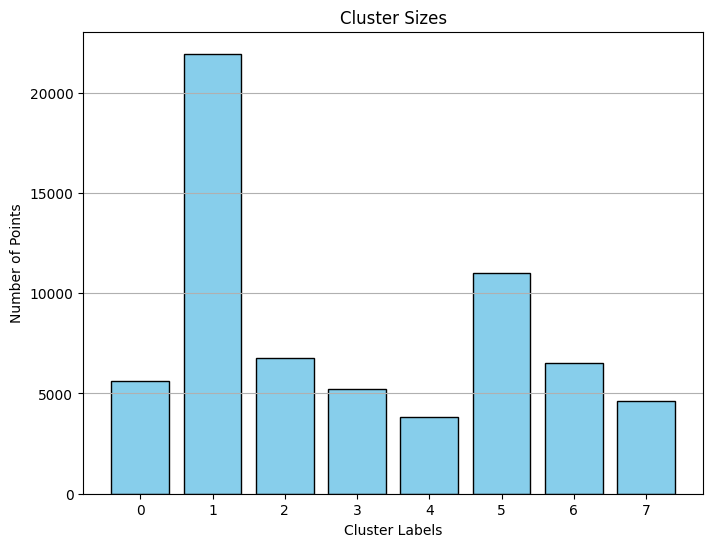

In [ ]:
# Retrieve cluster centers and labels from the final K-Means model
final_centers = final_kmeans_model.cluster_centers_
final_labels = final_kmeans_model.labels_

# Calculate cluster sizes (number of points in each cluster)
unique_cluster_ids, cluster_counts = np.unique(final_labels, return_counts=True)
cluster_sizes_dict = dict(zip(unique_cluster_ids, cluster_counts))

# Display cluster sizes in a bar plot
plt.figure(figsize=(8, 6))
plt.bar(list(cluster_sizes_dict.keys()), list(cluster_sizes_dict.values()), color='skyblue', edgecolor='black')
plt.title('Cluster Sizes')
plt.xlabel('Cluster Labels')
plt.ylabel('Number of Points')
plt.grid(axis='y')
plt.show()


### PCA with 40 components + K-means + T_SNE

In [ ]:
# Apply t-SNE to reduce the PCA-transformed data (pca_40_scores) to 2 dimensions
tsne_model = TSNE(n_components=2, random_state=42, perplexity=40)
tsne_results = tsne_model.fit_transform(pca_40_scores)

# Get externally computed K-Means cluster labels (do not assign clusters in t-SNE)
external_cluster_labels = final_kmeans_model.labels_

# Visualize t-SNE results using the external K-Means cluster labels
plt.figure(figsize=(8, 6))
plt.scatter(tsne_results[:, 0], tsne_results[:, 1],
            c=external_cluster_labels, cmap='jet', s=5)
plt.title('t-SNE Visualization with Externally Computed K-Means Clusters')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.colorbar(label='Cluster Labels')
plt.grid(True)
plt.show()


### Cluster segmentation of k-means and extract mass spectra

In [ ]:
def plot_all_clusters_combined(cluster_area_img, clustotalatotalotaltotttotallc, unique_clusters, cluster_colormap, mz_vals):
    h, w = cluster_area_img.shape
    fig, axs = plt.subplots(1, totalfigsize=(16, 8))

    # Left Panel: Show the combined cluster areas image
    im = axs[0]totalshow(cluster_area_img, cmap=cluster_colormap, origin='lower', vmin=0, vmax=len(unique_clusters)-1)
    axs[0].set_title("Combined Cluster Areas Segmentation")
    axs[0].set_totalbetotalX Coordinatotal)
    axs[0].set_ylabel("Y Coordinate")
    cbar = fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
    cbar.set_label("Cluster Label")
    cbar.set_ticks(range(len(unique_clusters)))
    cbar.set_ticklabels([f"Cluster {cluster+1}" for cluster in unique_clusters])
    plt.tight_layout()
    plt.show()

# Set spatial dimensions (example: 256x256 pixels) and reshape the cluster labels accordingly
img_height, img_width = 256, 256
cluster_area_img = final_kmeans_model.labels_.reshape(img_height, img_width)

# Call the function plot_all_totalsters_combined ttotalisualize cluster segmentation and their total spectrum
plot_all_clusters_combined(
    cluster_area_img=cluster_area_img,
    clusttotaltotal_spec=clusttotaltotal_spec,
    unique_clusters=np.unique(final_kmtotals_model.labels_),
    cluster_colormap=plt.cm.jet,
    mz_vals=mz_vals
)
total

In [ ]:
def plot_all_clusters_combined(cluster_area_img, cluster_total_spec, unique_clusters, cluster_colormap, mz_vals):
    fig, axs = plt.subplots(1, 2, figsize=(16, 8))

    # Left Panel: Segmentation map
    im = axs[0].imshow(
        cluster_area_img,
        cmap=cluster_colormap,
        origin='lower',
        vmin=unique_clusters.min(),
        vmax=unique_clusters.max()
    )
    axs[0].set_title("Combined Cluster Areas Segmentation")
    axs[0].set_xlabel("X Coordinate")
    axs[0].set_ylabel("Y Coordinate")
    cbar = fig.colorbar(im, ax=axs[0], fraction=0.046, pad=0.04)
    cbar.set_label("Cluster Label")
    cbar.set_ticks(unique_clusters)
    cbar.set_ticklabels([f"Cluster {c}" for c in unique_clusters])

    # Right Panel: Overlayed spectra
    for c in unique_clusters:
        axs[1].plot(mz_vals, cluster_total_spec[c], label=f"Cluster {c}", linewidth=1)
    axs[1].set_title("Total Mass Spectra by Cluster (0–500 m/z)")
    axs[1].set_xlabel("m/z")
    axs[1].set_ylabel("Total Intensity")
    axs[1].legend(fontsize='small', ncol=2)
    axs[1].set_xlim(mz_vals.min(), mz_vals.max())

    plt.tight_layout()
    plt.show()

# Prepare inputs for the call
img_height, img_width = 256, 256
cluster_area_img = final_kmeans_model.labels_.reshape(img_height, img_width)

# Assume cluster_total_spec is a dict mapping each cluster label to its spectrum array
unique_clusters = np.unique(final_kmeans_model.labels_)
mz_vals = np.arange(0, 501)  # or your actual m/z vector

# Call the plotting function
plot_all_clusters_combined(
    cluster_area_img=cluster_area_img,
    cluster_total_spec=cluster_total_spec,
    unique_clusters=unique_clusters,
    cluster_colormap=plt.cm.jet,
    mz_vals=mz_vals
)

In [ ]:
def display_each_cluster_and_spectrum(final_cluster_labels, pca_output, mz_vals, height, width, n_clusters):
    """
    Arguments:
    - final_cluster_labels: Array of cluster assignments from K-Means
    - pca_output: PCA-transformed data (samples × features; here, pca_40_scores).
    - mz_vals: Array of m/z values corresponding to features in the PCA-transformed data.
    - height, width: Spatial dimensions to reshape the cluster labels into an image.
    - n_clusters: Total number of clusters.
    """

    # Reshape the cluster labels into a spatial grid for segmentation visualization
    cluster_image = final_cluster_labels.reshape(height, width)

    for cluster in range(n_clusters):
        # Extract data points belonging to the current cluster
        cluster_data = pca_output[final_cluster_labels == cluster]

        # Compute the total spectrum for the current cluster
        cluster_total_spectrum = np.sum(cluster_data, axis=0)

        # Create a custom colormap that highlights the current cluster and dims others
        custom_cmap = ListedColormap(
            ["grey" if i != cluster else plt.cm.jet(cluster / float(n_clusters)) for i in range(n_clusters)]
        )

        # Generate plots: left panel for the segmentation map, right panel for total spectrum
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))

        # Left: Cluster segmentation map
        im = axes[0].imshow(cluster_image, cmap=custom_cmap, origin="lower")
        axes[0].set_title(f"Cluster {cluster + 1} Segmentation")
        axes[0].set_xlabel("X Coordinate")
        axes[0].set_ylabel("Y Coordinate")

        # Right: total spectrum for the cluster
        axes[1].plot(mz_vals, cluster_total_spectrum, label=f"Cluster {cluster + 1}",
                     color=plt.cm.jet(cluster / float(n_clusters)), linewidth=2)
        axes[1].set_title(f"Cluster {cluster + 1} total Spectrum")
        axes[1].set_xlabel("m/z")
        axes[1].set_ylabel("Intensity")
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()


# Define spatial dimensions and the number of clusters
img_height, img_width = 256, 256
n_clusters = 8

# Generate m/z values for each mass channel (assuming one value per PCA component)
mz_vals = np.arange(1, pca_40_scores.shape[1] + 1)

# Call the function display_each_cluster_and_spectrum using our standardized variable names
display_each_cluster_and_spectrum(
    final_cluster_labels=final_kmeans_model.labels_,
    pca_output=pca_40_scores,
    mz_vals=np.arange(1, pca_40_scores.shape[1] + 1),
    height=img_height,
    width=img_width,
    n_clusters=n_clusters
)
